# Proceso de prediccion

## Setup

In [1]:
# Importar bibliotecas
import os
import sys
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import pyfixest as pf
import seaborn as sns

warnings.filterwarnings("ignore")

In [2]:
#pip install scikit-learn

In [3]:
# Importar una funcion en python que ayuda a realizar graficos, tablas, etc
import py_helper_functions as da
# setup de los colores y formatos de graficos
sns.set_theme(rc=da.da_theme, palette=da.color)

In [4]:
# folders
path = "C:/Users/et396/OneDrive/Dropbox/"
base = "Docencia/UNAC/Evaluation/S1/Code/"

# Direccion de folder
data_in = path+base

In [5]:
# Information de base
data = pd.read_csv(data_in + "BP1.csv")

## Limpieza de data

In [6]:

# Revision y administracion de missings
data["fuel"] = data["fuel"].fillna("Missing")
data["condition"] = data["condition"].fillna("Missing")
data["drive"] = data["drive"].fillna("Missing")
data["cylinders"] = data["cylinders"].fillna("Missing")
data["transmission"] = data["transmission"].fillna("Missing")
data["type"] = data["type"].fillna("Missing")

# Solo filtrar y quedarse con casos de modeos hibridos
data = data.loc[data.Hybrid == 0].drop(["Hybrid"], axis=1)

# filtrar los casos de vehiculos de gas-fuelled
data = data.loc[data.fuel == "gas"]

# eliminar los vehiculos considerados fair y de nueva condicion, camiones
data = data.loc[~data.condition.isin(["new", "fair"])]

# eliminar valores poco realistas para el precio y el odómetro
data = data.loc[(data.price >= 500) & (data.price <= 25000) & (data.odometer <= 100)]

# eliminar si el precio es menor que 1000 y la condición es "como nuevo" o la antigüedad es menor que 8
data = data.loc[
    ~((data.price < 1000) & ((data.condition == "like new") | (data.age < 8)))
]

# eliminar casos de autos manuales
data = data.loc[~(data.transmission == "manual")]

# drop if truck
data = data.loc[~(data.type == "truck")]
# drop pricestr
data = data.drop(["pricestr"], axis=1)


## Proceso de generacion de base final

In [7]:
# DATA GENERATION & DESCRIPTIVES
# variuables y condiciones
data["cond_excellent"] = np.where(data["condition"] == "excellent", 1, 0)
data["cond_good"]      = np.where(data["condition"] == "good", 1, 0)
data["cond_likenew"]   = np.where(data["condition"] == "like new", 1, 0)
# cylinders
data["cylind6"]        = np.where(data["cylinders"] == "6 cylinders", 1, 0)
data.cylinders.value_counts()
data.cylind6.value_counts()
# age: quadratic, cubic
data["agesq"] = data["age"] ** 2
data["agecu"] = data["age"] ** 3
# odometer quadratic
data["odometersq"] = data["odometer"] ** 2

# Quedarse solo con los casos de la ciudad de chicago
data = data.loc[data.area == "chicago"]



## Analisis descriptivos

In [8]:
# Resumene stadistico
# data summary
data.loc[
    :,
    [
        "age",
        "odometer",
        "LE",
        "XLE",
        "SE",
        "cond_likenew",
        "cond_excellent",
        "cond_good",
        "cylind6",
    ],
].describe().T

,count,mean,std,min,25%,50%,75%,max
age,281.0,12.298932,5.892153,1.0000,7.00,13.0000,17.00,27.0
odometer,281.0,12.521702,5.172572,0.2319,8.14,13.6559,16.43,25.3
LE,281.0,0.192171,0.394710,0.0000,0.00,0.0000,0.00,1.0
XLE,281.0,0.071174,0.257575,0.0000,0.00,0.0000,0.00,1.0
SE,281.0,0.064057,0.245291,0.0000,0.00,0.0000,0.00,1.0
cond_likenew,281.0,0.053381,0.225193,0.0000,0.00,0.0000,0.00,1.0
cond_excellent,281.0,0.266904,0.443131,0.0000,0.00,0.0000,1.00,1.0
cond_good,281.0,0.238434,0.426886,0.0000,0.00,0.0000,0.00,1.0
cylind6,281.0,0.145907,0.353643,0.0000,0.00,0.0000,0.00,1.0


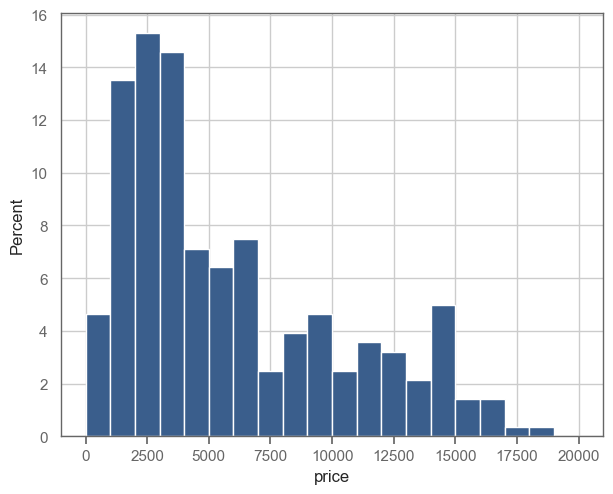

In [9]:
# Histograma
fig = sns.histplot(
    data,
    x="price",
    stat="percent",
    binwidth=1000,
    binrange=(1, 20000),
    alpha=1,
)

## Analisis de regresion

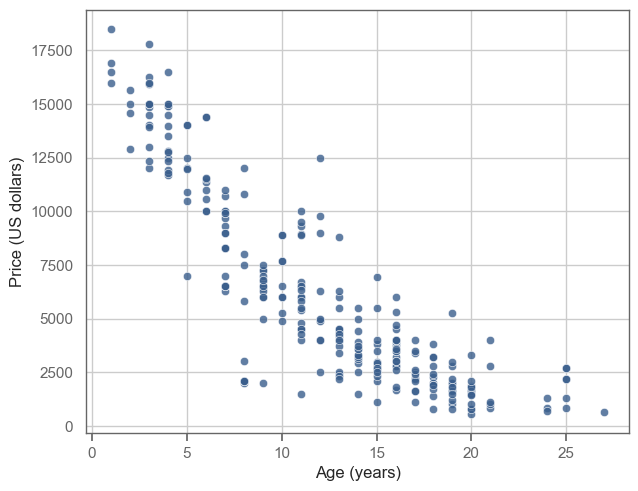

In [10]:
fig = sns.scatterplot(data=data, x="age", y="price", alpha=0.8)
#da.plot_loess(data, "age", "price", span=0.8)
plt.xlabel("Age (years)")
plt.ylabel("Price (US dollars)")
#plt.xticks(da.seq(0, 30, 5))
#plt.yticks(da.seq(0, 20000, 5000))
#da.add_margin(fig, x=0.01, y=0.01)
plt.show()

### Propuesta de modelos

In [11]:
###################################
# Regresion Lineal

# Model 1: Linear regression on age
model1 = "price ~ age + agesq"

# Models 2-5: Multiple linear regressions
# note: condition - missing will be baseline for regs
model2 = "price ~ age + agesq + odometer"
model3 = "price ~ age + agesq + odometer + odometersq + LE + cond_excellent + cond_good + dealer"
model4 = "price ~ age + agesq + odometer + odometersq + LE + XLE + SE + cond_likenew + cond_excellent + cond_good + cylind6 + dealer"
model5 = "price ~ age + agesq + odometer + odometersq + LE * age + XLE * age + SE * age + cond_likenew * age + cond_excellent * age + cond_good * age + cylind6 * age + odometer * age + dealer * age"

model_equations = [model1, model2, model3, model4, model5]

In [12]:
regs = []
for equation in model_equations:
    regs.append(pf.feols(equation, data, vcov="HC1"))

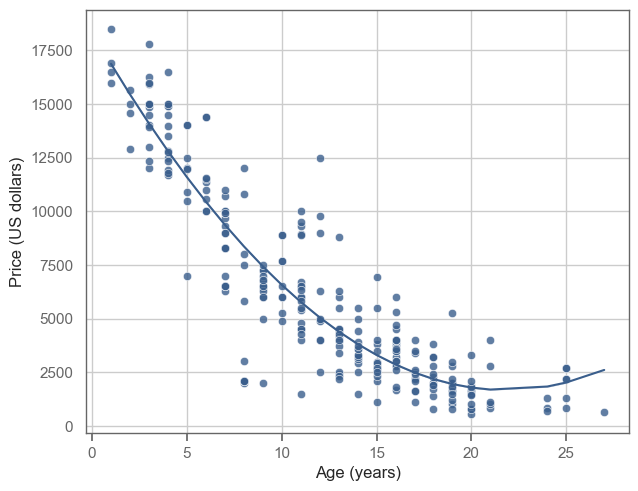

In [13]:
# Mostrar resultados de forma grafica
fig = sns.scatterplot(data=data, x="age", y="price", alpha=0.8)
#da.plot_loess(data, "age", "price", span=0.8)
data["reg0preds"] = regs[0].predict()
sns.lineplot(data, x="age", y="reg0preds")

plt.xlabel("Age (years)")
plt.ylabel("Price (US dollars)")
#plt.xticks(da.seq(0, 30, 5))
#plt.yticks(da.seq(0, 20000, 5000))
#da.add_margin(fig, x=0.01, y=0.01)
plt.show()

In [14]:
#Presentacion en formato de tabla
pf.etable(regs[:4])

GT(_tbl_data=   level_0             level_1                            0  \
0     coef                 age   -1530.088*** <br> (59.643)   
1     coef               agesq       35.048*** <br> (2.314)   
2     coef            odometer                                
3     coef          odometersq                                
4     coef                  LE                                
5     coef      cond_excellent                                
6     coef           cond_good                                
7     coef              dealer                                
8     coef                 XLE                                
9     coef                  SE                                
10    coef        cond_likenew                                
11    coef             cylind6                                
12    coef           Intercept  1.837E+04*** <br> (353.534)   
13   stats        Observations                          281   
14   stats           S.E. type                       hetero   
15   stats       R<sup>2</sup>                        0.847   
16   stats  Adj. R<sup>2</sup>                        0.846   

                              1                            2  \
0    -1149.223*** <br> (70.123)    -873.473*** <br> (82.351)   
1        27.653*** <br> (2.558)       18.214*** <br> (2.602)   
2     -303.840*** <br> (31.105)    -779.898*** <br> (88.245)   
3                                     18.808*** <br> (2.735)   
4                                      28.113 <br> (202.578)   
5                                     176.487 <br> (194.196)   
6                                     293.361 <br> (223.992)   
7                                    572.976* <br> (224.363)   
8                                                              
9                                                              
10                                                             
11                                                             
12  1.886E+04*** <br> (313.505)  1.943E+04*** <br> (418.947)   
13                          281                          281   
14                       hetero                       hetero   
15                        0.898                        0.913   
16                        0.897                        0.910   

                              3  
0     -836.643*** <br> (78.535)  
1        17.630*** <br> (2.472)  
2     -788.702*** <br> (84.644)  
3        19.200*** <br> (2.662)  
4        -20.482 <br> (207.509)  
5        190.403 <br> (208.324)  
6        321.558 <br> (233.367)  
7     822.649*** <br> (237.332)  
8        301.685 <br> (365.083)  
9      1338.787* <br> (527.717)  
10       558.674 <br> (393.994)  
11      -370.275 <br> (257.255)  
12  1.896E+04*** <br> (451.933)  
13                          281  
14                       hetero  
15                        0.919  
16                        0.916  , _body=<great_tables._gt_data.Body object at 0x00000208987EAD90>, _boxhead=Boxhead([ColInfo(var='level_0', type=<ColInfoTypeEnum.row_group: 3>, column_label='level_0', column_align='center', column_width=None), ColInfo(var='level_1', type=<ColInfoTypeEnum.stub: 2>, column_label='level_1', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None), ColInfo(var='2', type=<ColInfoTypeEnum.default: 1>, column_label='(3)', column_align='center', column_width=None), ColInfo(var='3', type=<ColInfoTypeEnum.default: 1>, column_label='(4)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000020898754E50>, _spanners=Spanners([SpannerInfo(spanner_id='price', spanner_level=1, spanner_label='price', spanner_units=None, spanner_pattern=None, vars=['0', '1', '2', '3'], built=None)]), _heading=Heading(title=None, subtitle=None, prehead

### Predicciones

In [15]:
# Seleccion de variables
data = data.loc[
    :,
    [
        "age",
        "agesq",
        "odometer",
        "odometersq",
        "SE",
        "LE",
        "XLE",
        "cond_likenew",
        "cond_excellent",
        "cond_good",
        "dealer",
        "price",
        "cylind6",
    ],
]

In [16]:
# Seleccion de nueva data
new = pd.DataFrame(
    pd.Series(
        {
            "age": 10,
            "agesq": 10**2,
            "odometer": 12,
            "odometersq": 12**2,
            "SE": 0,
            "LE": 1,
            "XLE": 0,
            "cond_likenew": 0,
            "cond_excellent": 1,
            "cond_good": 0,
            "dealer": 0,
            "price": np.nan,
            "cylind6": 0,
        }
    )
).T
new

,age,agesq,odometer,odometersq,SE,LE,XLE,cond_likenew,cond_excellent,cond_good,dealer,price,cylind6
0,10.0,100.0,12.0,144.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,NaN,0.0


In [17]:
reg1 = regs[0]
reg3 = regs[2]


In [18]:
table = (
    pd.concat(
        [reg.predict(new, interval="prediction", alpha=0.05) for reg in [reg1, reg3]],
    )
    .set_axis(["Model 1", "Model 3"], axis=0)
    .astype(int)
)

table["Point prediction"] = table["fit"]
table["Prediction Interval (95%)"] = (
    "[" + table["ci_low"].astype(str) + "-" + table["ci_high"].astype(str) + "]"
)
p80 = (
    pd.concat(
        [reg.predict(new, interval="prediction", alpha=0.2) for reg in [reg1, reg3]]
    )
    .set_axis(["Model 1", "Model 3"], axis=0)
    .astype(int)
)
table["Prediction Interval (80%)"] = (
    "[" + p80["ci_low"].astype(str) + "-" + p80["ci_high"].astype(str) + "]"
)

In [19]:
table.T.iloc[-3:, :]

,Model 1,Model 3
Point prediction,6569,6072
Prediction Interval (95%),[3081-10056],[3384-8760]
Prediction Interval (80%),[4293-8845],[4318-7826]


## Cross validation

In [20]:
n_fold = 4

cv_list = []
for equation in model_equations:
    cv_list.append(da.ols_crossvalidator(equation, data, n_fold, average_rmse=False))

# presentacion de modelos 
(
    pd.DataFrame(cv_list)
    .round(2)
    .assign(
        RMSE=lambda x: x["RMSE"].astype(int),
        BIC=lambda x: x["BIC"].astype(int),
        Coefficients=lambda x: x["Coefficients"].astype(int),
        Model=["Model " + str(i + 1) for i in range(len(model_equations))],
        Nvars=[1, 2, 5, 6, 6],
    )
    .filter(["Model", "Nvars", "Coefficients", "R-squared", "RMSE", "BIC"])
    .set_index("Model")
)


,Nvars,Coefficients,R-squared,RMSE,BIC
Model,,,,,
Model 1,1,3,0.85,1755,5012
Model 2,2,4,0.90,1433,4904
Model 3,5,9,0.91,1322,4887
Model 4,6,13,0.92,1273,4888
Model 5,6,22,0.92,1241,4925


In [21]:
# Presentacion de Cross validation k=4
pd.DataFrame(
    [cv["Test RMSE"] for cv in cv_list],
    index=["Model " + str(i + 1) for i in range(len(cv_list))],
    columns=["Fold" + str(i + 1) for i in range(len(cv_list[0]["Test RMSE"]))],
).assign(Average=lambda x: x.mean(axis=1)).T.round().astype(int)


,Model 1,Model 2,Model 3,Model 4,Model 5
Fold1,2184,1685,1517,1546,1496
Fold2,1591,1435,1333,1335,1410
Fold3,1925,1538,1476,1424,1495
Fold4,1541,1428,1429,1372,1438
Average,1810,1521,1439,1419,1460


### Training y Test dataset 

In [22]:
# Separamos la data para entrenamiento y test
sample_size = round(0.2 * data.shape[0]) - 1
np.random.seed(20180123)

from sklearn.model_selection import train_test_split

data_work, data_holdout = train_test_split(data, test_size=sample_size)

In [23]:
n_folds = 5

In [24]:
cv_list = []
for model in model_equations:
    cv_list += [da.ols_crossvalidator( model, data_work, n_folds)]

### Comparando modelos

In [25]:
compare_model_fits = (
    pd.DataFrame(cv_list)
    .round(2)
    .assign(
        Model=["M" + str(i + 1) for i in range(len(cv_list))],
        BIC=lambda x: x["BIC"].astype(int),
        Coefficients=lambda x: x["Coefficients"].astype(int),
    )
    .filter(["Model", "Coefficients", "R-squared", "BIC", "Training RMSE", "Test RMSE"])
)
compare_model_fits

,Model,Coefficients,R-squared,BIC,Training RMSE,Test RMSE
0,M1,3,0.86,4031,1742.70,1745.86
1,M2,4,0.90,3945,1422.45,1427.62
2,M3,9,0.92,3926,1280.99,1313.13
3,M4,13,0.92,3939,1252.17,1338.46
4,M5,22,0.93,3975,1206.97,1409.88


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


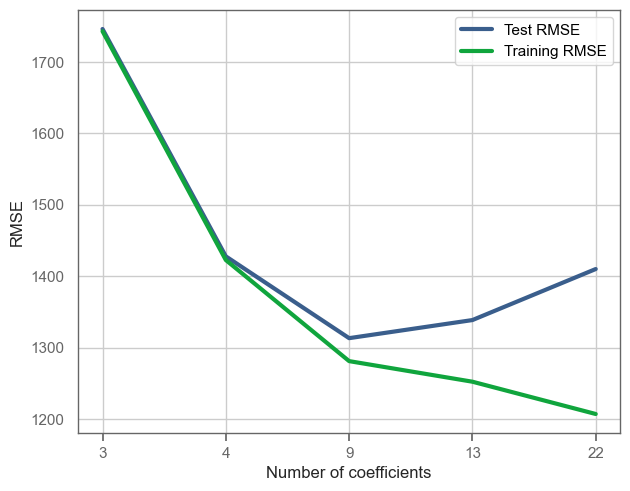

In [26]:
df_melted = compare_model_fits.melt(
    id_vars="Coefficients", value_vars=["Test RMSE", "Training RMSE"]
).assign(Coefficients=lambda x: x["Coefficients"].astype(str))

sns.lineplot(data=df_melted, x="Coefficients", y="value", hue="variable", linewidth=3)
plt.xlabel("Number of coefficients")
plt.ylabel("RMSE")
#plt.ylim(30, 43)
#plt.yticks(np.arange(30, 44, 2))
plt.legend(title="")
plt.show()